# 3E - Estabilidade: o sinal vale antes e depois da mudanca de regime?

**Pergunta especifica.** As relacoes que sobreviveram ao 3D valem em 1993-2009 E em 2010-presente, ou dependem de um regime especifico do Pacifico?

**Objetivo.** Aplicar o filtro final do protocolo e fechar o conjunto defensavel (= 3D interseccao 3E).

**Justificativa.** O Pacifico mudou de comportamento ~2010 (enfraquecimento do lead do WWV, documentado). Testar dois subperiodos protege contra sinais de epoca.

**Metodologia.** Reavaliar cada sobrevivente do 3D no seu melhor lag, em 1993-2009 e 2010-hoje. Estavel = mesmo sinal e p_efetivo<0.05 em ambos.

**Saidas.** `phase3E_estabilidade.csv` + scatter r1 x r2 e mapas lon x lag por subperiodo.

In [1]:
import sys; sys.path.insert(0,'.')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import fase3_utils as u
from nino_brasil.stats.significance import effective_sample_size, correlation_p_value
w=pd.read_csv(u.FEAT/'phase3_indices_semanais.csv',parse_dates=['week_ending_sunday']).set_index('week_ending_sunday')
best=pd.read_csv(u.STATS/'phase3D_ranking_significativo.csv').set_index('variavel')
def cat(wd,v,lag):
    x=wd[v].shift(lag); y=wd['nino34_ssta']; m=x.notna()&y.notna()
    if m.sum()<80: return np.nan,np.nan
    r=float(np.corrcoef(x[m],y[m])[0,1]); return r,correlation_p_value(r,effective_sample_size(x[m].values,y[m].values))
rows=[]
for v,row in best.iterrows():
    lag=int(row['lag_semanas'])
    r1,p1=cat(w.loc['1993-01-01':'2009-12-31'],v,lag); r2,p2=cat(w.loc['2010-01-01':],v,lag)
    rows.append({'variavel':v,'lag_semanas':lag,'r_full':round(row['r'],3),'r_1993_2009':round(r1,3),'p_1993_2009':round(p1,4),'r_2010_hoje':round(r2,3),'p_2010_hoje':round(p2,4),'estavel':bool((np.sign(r1)==np.sign(r2)) and p1<0.05 and p2<0.05)})
est=pd.DataFrame(rows).set_index('variavel'); u.save_table(est,'phase3E_estabilidade.csv')
print('ESTABILIDADE por variavel:')
for v,r in est.iterrows(): print(f"  {v:22s} lag{int(r.lag_semanas):2d}  r(93-09)={r.r_1993_2009:+.2f}(p={r.p_1993_2009:.3f})  r(10-hoje)={r.r_2010_hoje:+.2f}(p={r.p_2010_hoje:.3f})  {'ESTAVEL' if r.estavel else 'INSTAVEL'}")

[tabela] data/processed/parquet/statistics/phase3E_estabilidade.csv
ESTABILIDADE por variavel:
  ohc_0_100              lag 1  r(93-09)=+0.90(p=0.000)  r(10-hoje)=+0.91(p=0.000)  ESTAVEL
  t50m                   lag 0  r(93-09)=+0.88(p=0.000)  r(10-hoje)=+0.90(p=0.000)  ESTAVEL
  tilt_m                 lag 0  r(93-09)=+0.80(p=0.001)  r(10-hoje)=+0.81(p=0.001)  ESTAVEL
  ssh_m                  lag 6  r(93-09)=+0.78(p=0.000)  r(10-hoje)=+0.76(p=0.001)  ESTAVEL
  tcwv_anom              lag 0  r(93-09)=+0.72(p=0.000)  r(10-hoje)=+0.79(p=0.000)  ESTAVEL
  tilt_slope             lag 0  r(93-09)=+0.76(p=0.001)  r(10-hoje)=+0.81(p=0.000)  ESTAVEL
  ohc_0_300              lag 6  r(93-09)=+0.74(p=0.001)  r(10-hoje)=+0.73(p=0.002)  ESTAVEL
  sshf_anom              lag 0  r(93-09)=-0.77(p=0.000)  r(10-hoje)=-0.76(p=0.000)  ESTAVEL
  ohc_0_700              lag 6  r(93-09)=+0.71(p=0.002)  r(10-hoje)=+0.69(p=0.002)  ESTAVEL
  t100m                  lag 7  r(93-09)=+0.70(p=0.004)  r(10-hoje)=+0.69(p=0

[figura] data/processed/figures/fase3/3E1_scatter_estabilidade.png


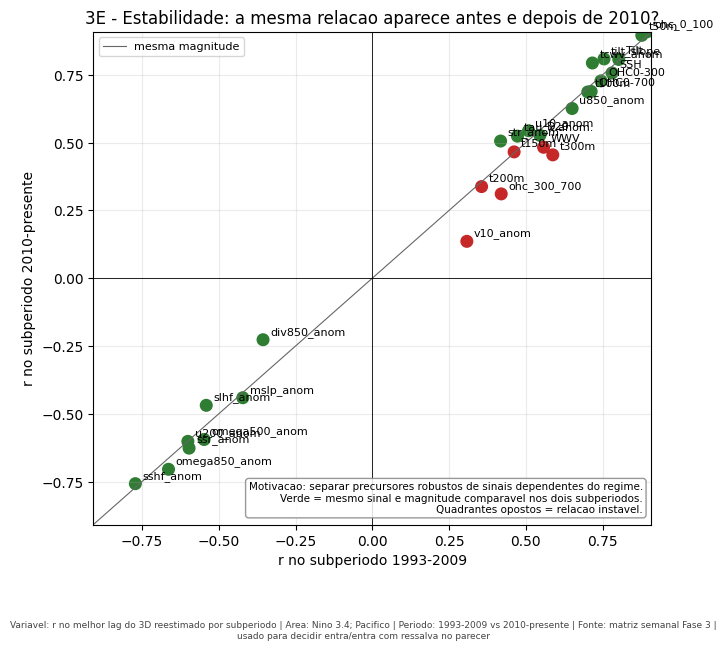

In [2]:
fig, ax = plt.subplots(figsize=(7.2, 6.4))
cores = est['estavel'].map({True:'#2e7d32', False:'#c62828'})
ax.scatter(est['r_1993_2009'], est['r_2010_hoje'], c=cores, s=70)
for var, r in est.iterrows():
    label_var = r['variavel'] if 'variavel' in est.columns else var
    ax.annotate(u.var_label(label_var, short=True), (r['r_1993_2009'], r['r_2010_hoje']), xytext=(5, 4), textcoords='offset points', fontsize=8)
lim = max(abs(est[['r_1993_2009','r_2010_hoje']].to_numpy()).max(), 0.5)
ax.plot([-lim, lim], [-lim, lim], color='0.4', lw=.8, label='mesma magnitude')
ax.axhline(0, color='k', lw=.6)
ax.axvline(0, color='k', lw=.6)
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_xlabel('r no subperiodo 1993-2009')
ax.set_ylabel('r no subperiodo 2010-presente')
ax.set_title('3E - Estabilidade: a mesma relacao aparece antes e depois de 2010?')
ax.grid(alpha=.25)
ax.legend(fontsize=8)
u.add_note(ax, 'Motivacao: separar precursores robustos de sinais dependentes do regime.\nVerde = mesmo sinal e magnitude comparavel nos dois subperiodos.\nQuadrantes opostos = relacao instavel.', loc='lower right')
u.stamp_caption(fig, variavel='r no melhor lag do 3D reestimado por subperiodo', area='Nino 3.4; Pacifico', periodo='1993-2009 vs 2010-presente', fonte='matriz semanal Fase 3', extra='usado para decidir entra/entra com ressalva no parecer')
u.save_fig(fig, '3E1_scatter_estabilidade.png')
plt.show()


[figura] data/processed/figures/fase3/3E2_mapa_lon_lag_subperiodos.png


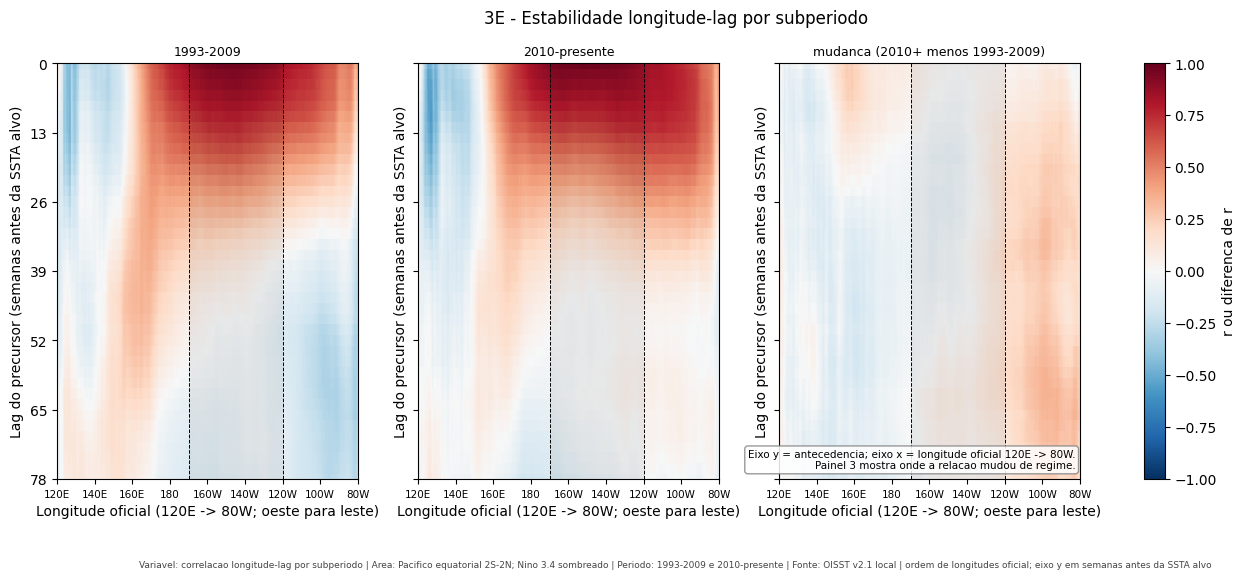

In [3]:
eq = u.load_eqband_weekly()
tgt = w['nino34_ssta']
def ll(eqd, tg, lags):
    a, tt = eqd.align(tg, join='inner', axis=0)
    tv = tt.values
    out = np.full((len(lags), a.shape[1]), np.nan)
    for i, l in enumerate(lags):
        X = a.values if l == 0 else a.iloc[:-l].values
        y = tv if l == 0 else tv[l:]
        for j in range(X.shape[1]):
            x = X[:, j]
            m = np.isfinite(x) & np.isfinite(y)
            if m.sum() > 30:
                out[i, j] = np.corrcoef(x[m], y[m])[0, 1]
    return out
lags = list(range(0, 79, 2))
sub1 = ll(eq.loc['1993':'2009'], tgt.loc['1993':'2009'], lags)
sub2 = ll(eq.loc['2010':], tgt.loc['2010':], lags)
lon = eq.columns.values.astype(float)
fig, axes = plt.subplots(1, 3, figsize=(16.5, 5.4), sharey=True)
for ax, mat, title in zip(axes, [sub1, sub2, sub2-sub1], ['1993-2009', '2010-presente', 'mudanca (2010+ menos 1993-2009)']):
    pc = ax.pcolormesh(lon, lags, mat, cmap='RdBu_r', vmin=-1, vmax=1, shading='auto')
    u.add_nino34_lon_band(ax, label=False)
    u.format_lon_axis(ax)
    u.format_lag_axis(ax, max_lag=max(lags))
    ax.set_title(title, fontsize=9)
axes[0].set_ylabel('Lag do precursor (semanas antes da SSTA alvo)')
fig.colorbar(pc, ax=axes, label='r ou diferenca de r')
fig.suptitle('3E - Estabilidade longitude-lag por subperiodo')
u.add_note(axes[-1], 'Eixo y = antecedencia; eixo x = longitude oficial 120E -> 80W.\nPainel 3 mostra onde a relacao mudou de regime.', loc='lower right')
u.stamp_caption(fig, variavel='correlacao longitude-lag por subperiodo', area='Pacifico equatorial 2S-2N; Nino 3.4 sombreado', periodo='1993-2009 e 2010-presente', fonte='OISST v2.1 local', extra='ordem de longitudes oficial; eixo y em semanas antes da SSTA alvo')
u.save_fig(fig, '3E2_mapa_lon_lag_subperiodos.png')
plt.show()


**Leitura do 3E.** Conjunto defensavel (estavel nos dois regimes): **tilt, SSH, OHC 0-300/0-700, D20 e tau_x_anom**. **Regime-dependente (entra com ressalva):** WWV perde significancia pos-2010, coerente com limitacoes conhecidas da recarga basinwide. Relacao instavel e achado fisico/metodologico a declarar no parecer, nao descarte automatico.
